# 06 — Time Series Analysis (Task 9)

Brief section 10. Decompose weekly revenue into trend/seasonality, note the
absence of Saturday orders and the strong Q4/November peak, and discuss
forecasting (ARIMA/SARIMA) qualitatively. Honest limitation: only two years of
data = two seasonal cycles, thin for annual seasonality.

In [14]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

clean = pd.read_csv('../data/processed/invoice_lines_clean.csv', parse_dates=['InvoiceDate'])
customers = pd.read_csv('../data/processed/customer_table.csv')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

## Weekly revenue series

<Axes: title={'center': 'Weekly revenue'}, xlabel='InvoiceDate'>

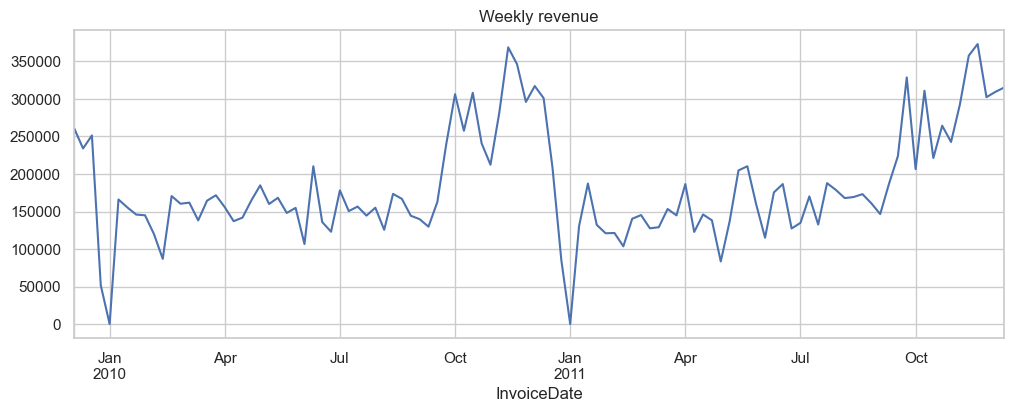

In [16]:
weekly_revenue = (clean[~clean['IsCancellation']]
                   .set_index('InvoiceDate')['LineRevenue']
                   .resample('W').sum())
weekly_revenue.plot(figsize=(12, 4), title='Weekly revenue')

## Decomposition

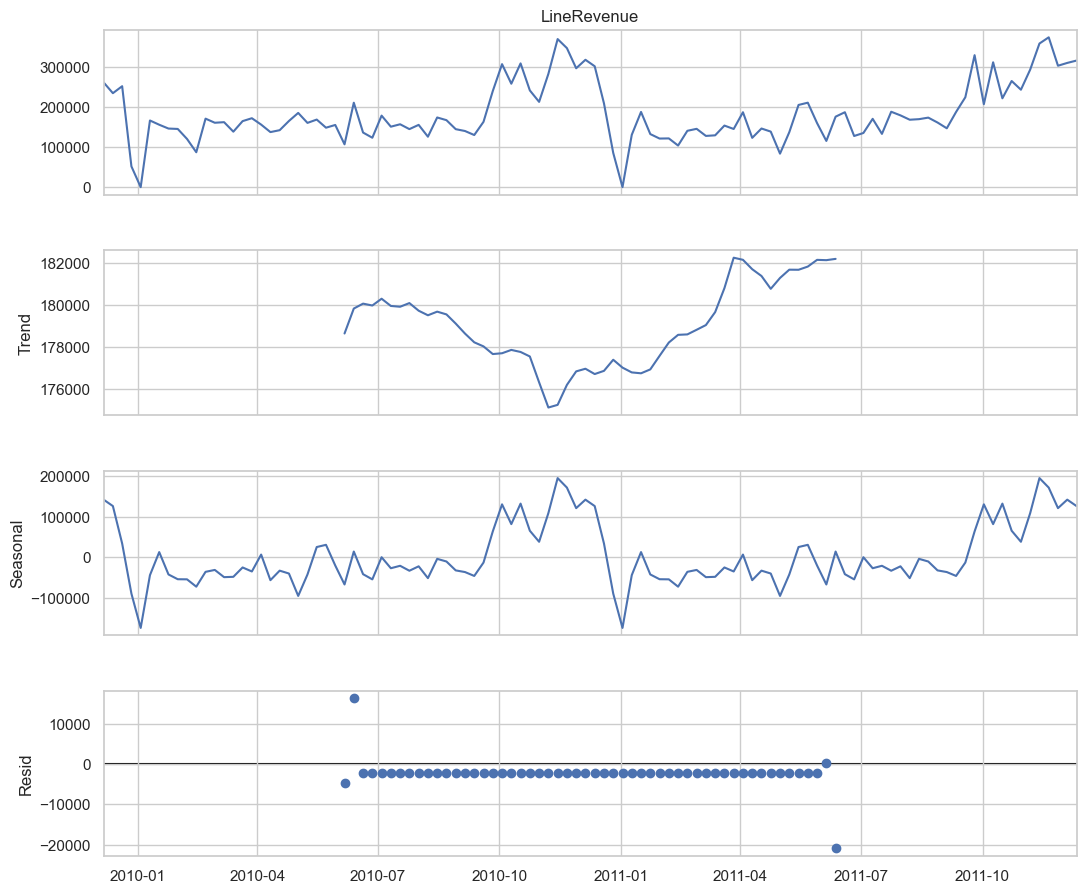

In [17]:
decomposition = seasonal_decompose(
    weekly_revenue,
    model='additive',
    period=52
)

fig = decomposition.plot()
fig.set_size_inches(12, 10)

plt.show()

## Day-of-week pattern (no Saturday orders)

In [18]:
# Create day of the week from InvoiceDate
clean['Day'] = clean['InvoiceDate'].dt.day_name()

# Calculate total revenue for each day
day_revenue = clean[~clean['IsCancellation']].groupby('Day')['LineRevenue'].sum()

# Set correct order for days
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

# Reorder the results
day_revenue = day_revenue.reindex(day_order)

# Display
day_revenue

Day
Monday       3416593.66
Tuesday      3802999.66
Wednesday    3375311.19
Thursday     4010215.52
Friday       2959872.28
Saturday        9803.05
Sunday       1785174.11
Name: LineRevenue, dtype: float64

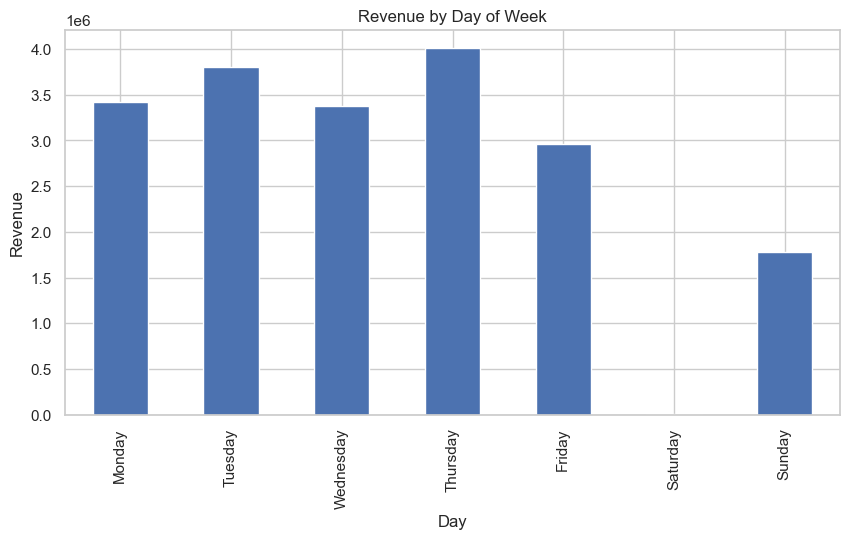

In [19]:
day_revenue.plot(
    kind='bar',
    figsize=(10, 5),
    title='Revenue by Day of Week'
)

plt.ylabel('Revenue')
plt.xlabel('Day')
plt.show()

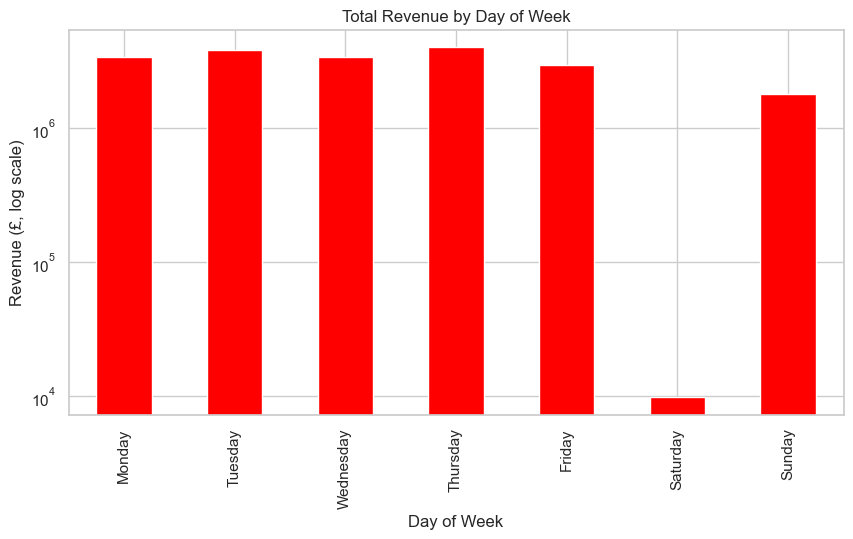

In [20]:
day_revenue.plot(
    kind='bar',
    figsize=(10, 5),
    title='Total Revenue by Day of Week',
    logy=True,
    color='red'
)

plt.ylabel('Revenue (£, log scale)')
plt.xlabel('Day of Week')
plt.show()

# Forecasting Discussion

Historical weekly revenue data could be used to forecast future revenue. 
Forecasting would allow the organization to estimate expected sales for upcoming 
weeks or months based on historical revenue patterns, trends, and seasonal effects.

In this project, forecasting could support inventory planning, staffing decisions, 
marketing campaign timing, and cash-flow planning. For example, if future revenue 
is expected to increase during the Q4 period, the organization could prepare 
inventory and operational resources in advance.

Although forecasting is not required for the current analysis, it could be added 
as a future extension of the project using the historical weekly revenue series.


# ARIMA and SARIMA

ARIMA (AutoRegressive Integrated Moving Average) could be used to forecast future 
revenue using historical time-dependent observations. ARIMA considers patterns in 
previous observations and the relationship between past and current values to 
generate future forecasts.

For this project, an ARIMA model could be applied to the weekly revenue series to 
forecast future revenue. The model could be evaluated using a time-based train-test 
split and forecasting accuracy measures such as MAE or RMSE.

If the revenue series contains a strong repeating seasonal pattern, SARIMA 
(Seasonal ARIMA) could be considered. SARIMA extends ARIMA by incorporating 
seasonal behaviour, making it suitable when revenue follows recurring patterns 
over time.

However, the dataset contains approximately two years of historical data. This 
provides only around two annual seasonal cycles, which is relatively limited for 
reliably identifying long-term annual seasonality. Therefore, any annual or Q4 
seasonal pattern should be interpreted cautiously. Additional historical data 
would improve the reliability of seasonal forecasting.

# Business Application
## Possible Business Applications

Time series analysis could provide several practical applications for the 
online retailer.

### Inventory Planning
Revenue forecasts could help the organization estimate future demand and prepare 
inventory before high-demand periods such as Q4 and November. This could help 
reduce the risk of stock shortages.

### Staffing and Operational Planning
Expected changes in sales volume could support workforce planning. Additional 
warehouse, order-processing, and customer-support resources could be arranged 
during periods of higher expected demand.

### Marketing Campaign Timing
Seasonal and forecasted revenue patterns could help the organization schedule 
marketing campaigns during periods where customer demand is expected to be higher.

### Cash-Flow Planning
Revenue forecasts could help management estimate future cash inflows and plan 
purchasing, operating expenses, and other financial requirements.

# Organizational Benefits

## Expected Organizational Benefits

Incorporating time series analysis could provide the organization with several 
potential benefits:

- Better inventory availability through more informed demand planning.
- Reduced risk of stock-outs during high-demand periods.
- Improved workforce and operational resource planning.
- Better timing of marketing campaigns and promotional activities.
- Improved cash-flow planning based on expected future revenue.
- More informed operational and strategic decision-making.
- Earlier identification of changes in revenue trends and seasonal demand.

Overall, time series analysis could complement the customer-level repurchase and 
value prediction models by providing a broader view of how business revenue 
changes over time.